# 02 — Run Preprocessing

Apply contrast enhancement and anisotropic diffusion to prepare data for GMM segmentation.

In [2]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path

from research_ct.io.volume_loader import Load_Slice_Stack
from research_ct.preprocessing.config import Preprocessing_Config
from research_ct.preprocessing.pipeline import Preprocess_For_Gmm
from research_ct.preprocessing.pipeline_revised import Preprocess_For_Gmm_Revised

from research_ct.visualization.histogram_diagnostics_viewer import (
    Plot_Histogram_Comparison,
    Plot_Slice_Histograms,
)

# Create figures directory
fig_dir = Path(r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output\figures")
fig_dir.mkdir(exist_ok=True)


# Load raw data
DATA_DIR = Path(r"C:\Users\gabri\Documento\Mitacs\research_ct\data\raw")
Volume = Load_Slice_Stack(DATA_DIR, Pattern="*.tif*")
print(f"Loaded: {Volume.shape}")

[Load_Slice_Stack] 201 slices from C:\Users\gabri\Documento\Mitacs\research_ct\data\raw
[Load_Slice_Stack] Volume: (201, 1828, 2165), range [0.0, 60735.0]
Loaded: (201, 1828, 2165)


## Gaussian background and noise reduction

Use Gaussian bacground and noise reduction. Avoid historgram shape reductions.

In [3]:
print("\nRunning revised preprocessing...")
Processed_Volume, Diagnostics = Preprocess_For_Gmm_Revised(
    Volume,
    Background_Sigma=None,  # Auto-estimate
    Noise_Sigma=0.8,
    Clip_Low_Percentile=0.1,
    Clip_High_Percentile=99.9,
    Check_Stationarity=True,
    Verbose=True,
)


Running revised preprocessing...
[Preprocess_GMM] Input: (201, 1828, 2165), dtype=float64, range [0.0, 60735.0]

[Step 1/4] Background correction (sigma=91.4)...
[Step 1/4] Done in 570.3s. Range: [0.0, 59384.9]

[Step 2/4] Noise reduction (sigma=0.8)...
[Step 2/4] Done in 15.9s. Range: [1.4, 52540.5]

[Step 3/4] Checking slice stationarity...
[Step 3/4] Stationarity: False (similarity=0.002)
[Step 3/4] Applying per-slice standardization...

[Step 4/4] Global normalization (0.1-99.9 percentiles)...
[Step 4/4] Done in 8.9s. Range: [0.0, 255.0]

[Diagnostics] Assessing GMM readiness...
[Diagnostics] Modes: 2, Skew: -2.57, Kurt: 12.52
[Diagnostics] Readiness score: 0.60
[Diagnostics] Good: Proceed with GMM, monitor convergence.


## Histogram inspection 

In [4]:
# Execute plotting
Plot_Histogram_Comparison(
    Raw_Volume=Volume,
    Processed_Volume=Processed_Volume,
    Output_Path=fig_dir / "histogram_before_after.png",
    N_Bins=256,
    Exclude_Zero=True,  # Focus on materials, exclude air
    Focus_Range=None,  # Auto-zoom to material region
)

[Plot_Histogram_Comparison] Saved → C:\Users\gabri\Documento\Mitacs\research_ct\data\output\figures\histogram_before_after.png


In [5]:
# Plot for both raw and processed
Plot_Slice_Histograms(
    Volume,
    fig_dir / "histogram_per_slice_raw.png",
    N_Slices=5,
    Exclude_Zero=True,
)

Plot_Slice_Histograms(
    Processed_Volume,
    fig_dir / "histogram_per_slice_processed.png",
    N_Slices=5,
    Exclude_Zero=True,
)

[Plot_Slice_Histograms] Saved → C:\Users\gabri\Documento\Mitacs\research_ct\data\output\figures\histogram_per_slice_raw.png
[Plot_Slice_Histograms] Saved → C:\Users\gabri\Documento\Mitacs\research_ct\data\output\figures\histogram_per_slice_processed.png


=== Before/After Histogram Comparison ===


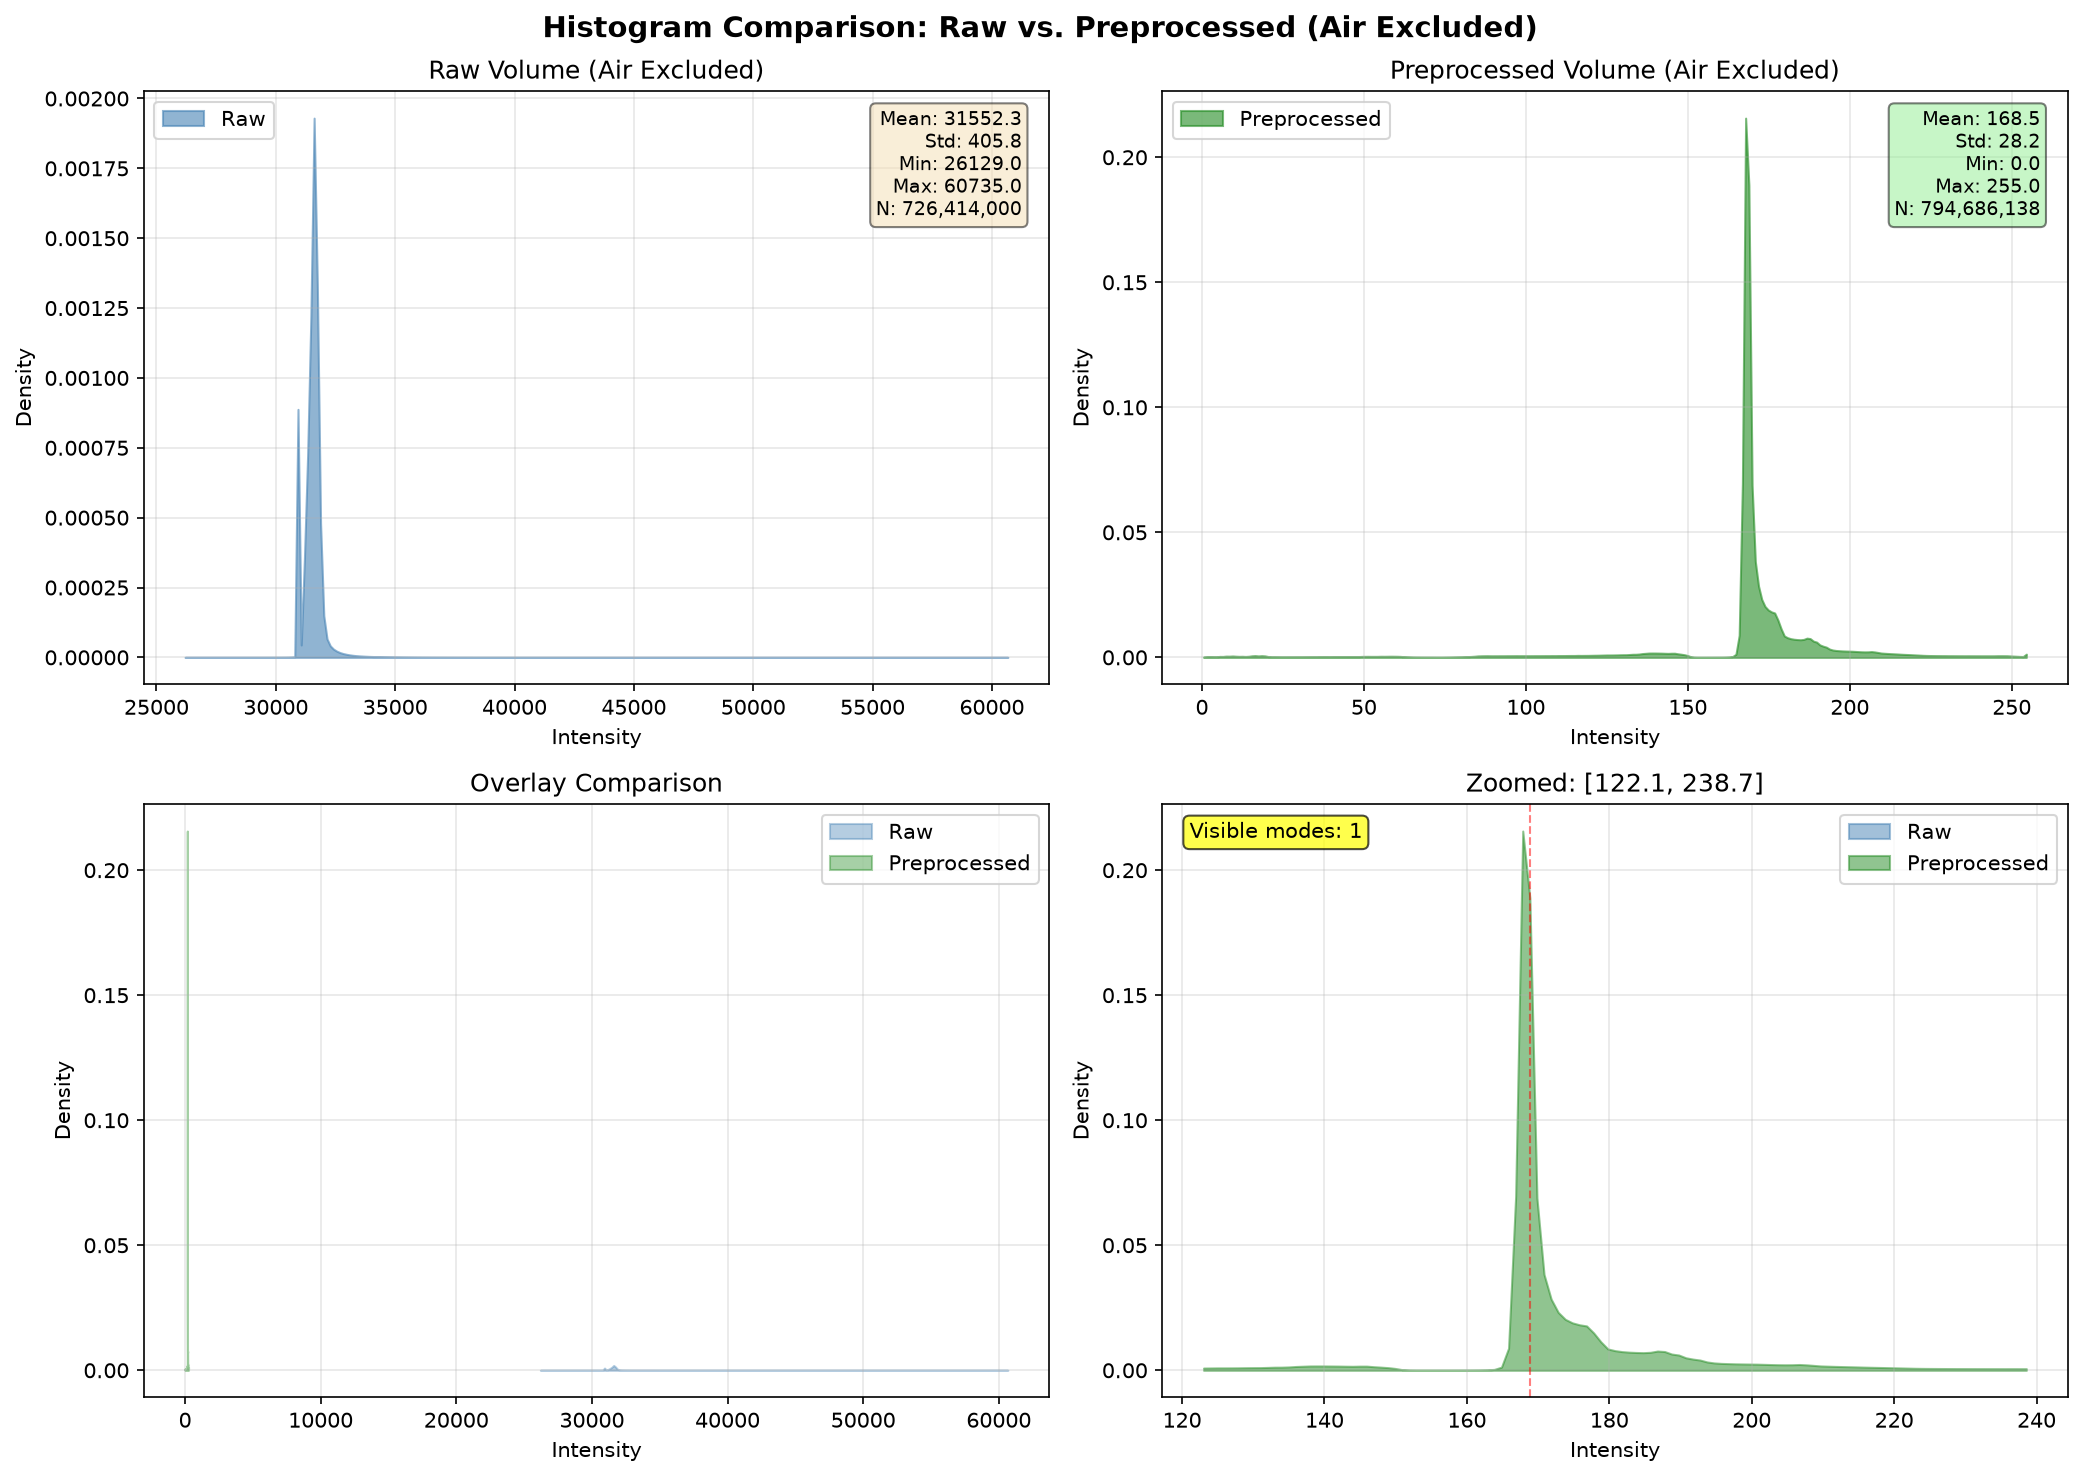


=== Raw Per-Slice Histograms ===


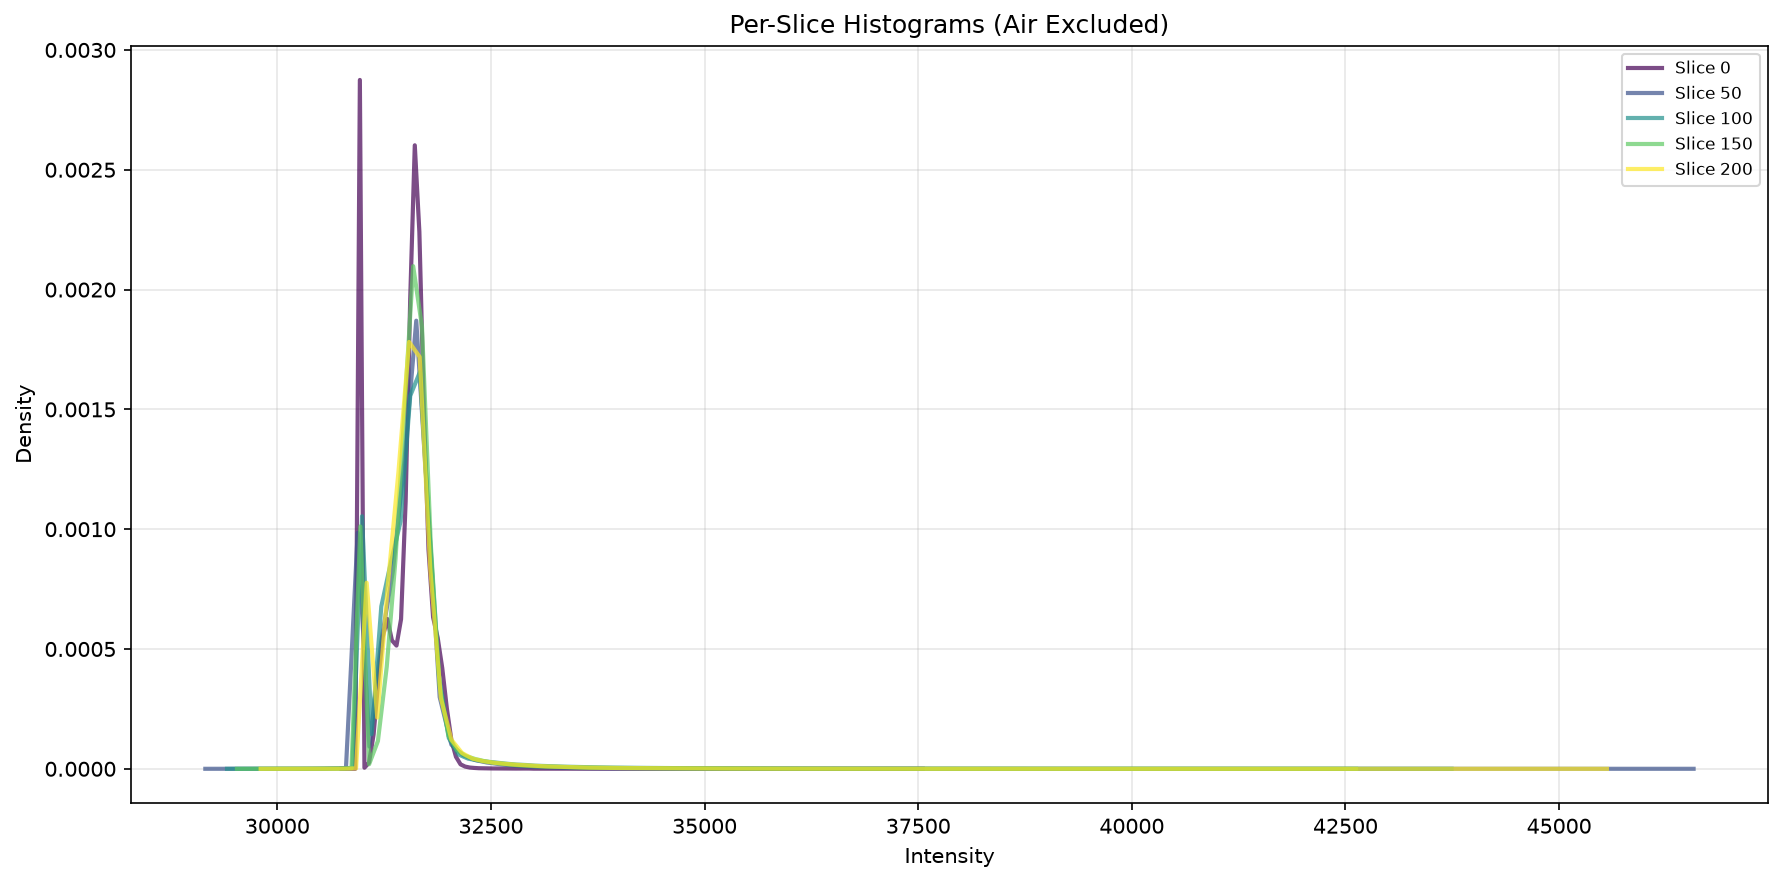


=== Processed Per-Slice Histograms ===


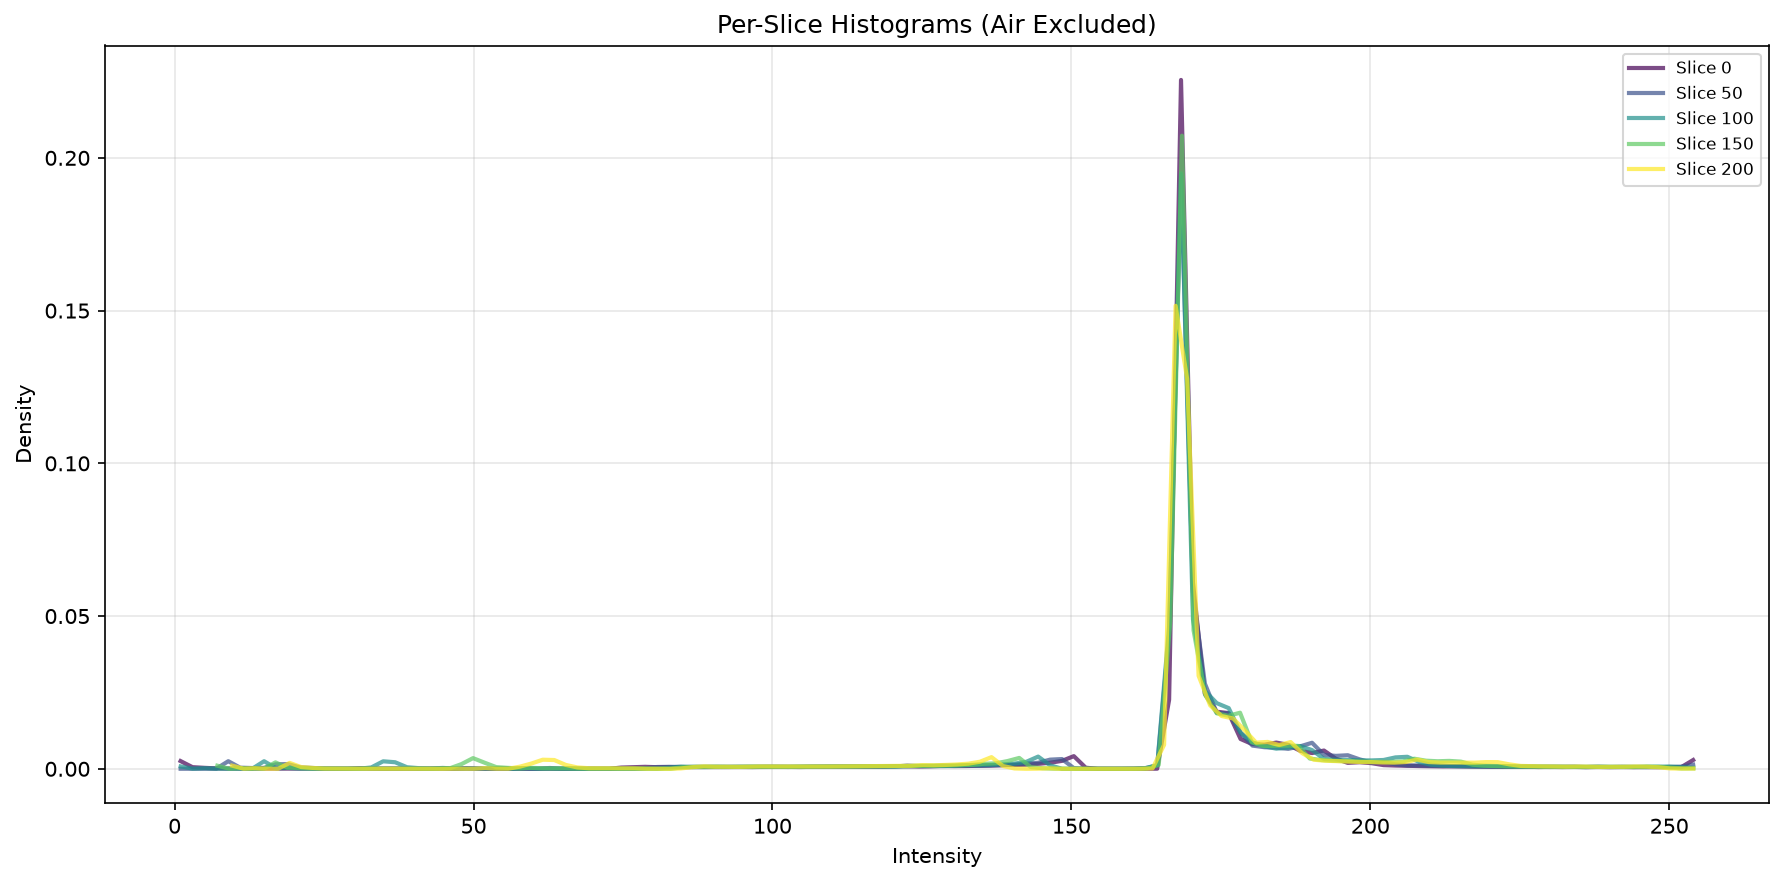

In [6]:
from IPython.display import Image, display

print("=== Before/After Histogram Comparison ===")
display(Image(filename=fig_dir / "histogram_before_after.png"))

print("\n=== Raw Per-Slice Histograms ===")
display(Image(filename=fig_dir / "histogram_per_slice_raw.png"))

print("\n=== Processed Per-Slice Histograms ===")
display(Image(filename=fig_dir / "histogram_per_slice_processed.png"))

## Select Configuration

Use `Gmm_Ready` preset (no thresholding — let GMM handle separation).

In [ ]:
Config = Preprocessing_Config.From_Preset("Gmm_Ready")
print(f"Preset: {Config._Preset_Name}")
print(f"Top-hat radius: {Config.Radius}")
print(f"CLAHE kernel: {Config.Clahe_Kernel}")
print(f"Diffusion iterations: {Config.Diffusion_Iterations}")
print(f"Diffusion kappa: {Config.Diffusion_Kappa}")
print(f"Saturation percentiles: {Config.Saturation_Percentiles}")

## Run Pipeline

This may take several minutes for large volumes.

In [ ]:
Processed, Diagnostics = Preprocess_For_Gmm(
    Volume,
    Config,
    Out_Dir=Path(r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output\diagnostics"),
    Expected_Pages=200,  # Set if known
)

## Inspect Diagnostics

Edge strength profile and page peak detection.

In [ ]:
from IPython.display import Image, display

# Display saved diagnostic plots
diag_dir = Path(r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output\diagnostics")
if (diag_dir / "edge_strength.png").exists():
    display(Image(diag_dir / "edge_strength.png"))
if (diag_dir / "histogram.png").exists():
    display(Image(diag_dir / "histogram.png"))

## Compare Raw vs Processed

Visualize the effect of preprocessing on representative slices.

In [ ]:
# Create figures directory
fig_dir = Path(
    r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output\figures")
fig_dir.mkdir(exist_ok=True)



In [8]:
D = Volume.shape[0]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, z in enumerate([D//4, D//2, 3*D//4]):
    # Raw
    axes[0, i].imshow(Volume[z], cmap='gray')
    axes[0, i].set_title(f'Raw — Z={z}')
    axes[0, i].axis('off')
    
    # Processed
    axes[1, i].imshow(Processed_Volume[z], cmap='gray')
    axes[1, i].set_title(f'Processed — Z={z}')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Raw', fontsize=12)
axes[1, 0].set_ylabel('Processed', fontsize=12)
plt.suptitle('Preprocessing Comparison', fontsize=14)
plt.tight_layout()
plt.show()

plt.savefig(fig_dir / "Preprocessing Comparison.png", dpi=300, bbox_inches="tight")
plt.close()

C:\Users\gabri\AppData\Local\Temp\ipykernel_19172\3706070438.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Histogram Comparison

Check if preprocessing improved separability.

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(Volume.ravel(), bins=256, density=True, alpha=0.7, color='gray')
axes[0].set_title('Raw Intensity Histogram')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Density')
axes[0].grid(True, alpha=0.3)

axes[1].hist(Processed_Volume.ravel(), bins=256, density=True, alpha=0.7, color="steelblue")
axes[1].set_title('Processed Intensity Histogram')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Density')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.savefig(fig_dir / "Processed Intensity Histogram.png", dpi=300, bbox_inches="tight")
plt.close()

C:\Users\gabri\AppData\Local\Temp\ipykernel_19172\466909572.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Save Processed Volume

Store for next step (GMM fitting).

In [10]:
from research_ct.io.volume_saver import Save_As_Numpy

Save_As_Numpy(
    Processed_Volume,
    r"C:\Users\gabri\Documento\Mitacs\research_ct\data\output\processed\preprocessed_volume.npz",
)
print("Saved to ../data/processed/preprocessed_volume.npz")

[Save_As_Numpy] Saved → C:\Users\gabri\Documento\Mitacs\research_ct\data\output\processed\preprocessed_volume.npz
Saved to ../data/processed/preprocessed_volume.npz
